---
# Loading and visualizing data 
Importing the:
- Train set 
- Test set
- Validation set


In [71]:
import pandas as pd
import torch
import numpy as np

In [2]:
#pytorch version
print(torch.__version__)

2.3.1+cu121


# ESM-2 embedding

In [10]:
import pathlib
from esm import FastaBatchedDataset, pretrained


In [7]:
def extract_embeddings(model_name, fasta_file, output_dir, tokens_per_batch=4096, seq_length=1022,repr_layers=[33]):
    
    model, alphabet = pretrained.load_model_and_alphabet(model_name)
    model.eval()

    if torch.cuda.is_available():
        model = model.cuda()
        
    dataset = FastaBatchedDataset.from_file(fasta_file)
    batches = dataset.get_batch_indices(tokens_per_batch, extra_toks_per_seq=1)

    data_loader = torch.utils.data.DataLoader(
        dataset, 
        collate_fn=alphabet.get_batch_converter(seq_length), 
        batch_sampler=batches
    )

    output_dir.mkdir(parents=True, exist_ok=True)
    
    with torch.no_grad():
        for batch_idx, (labels, strs, toks) in enumerate(data_loader):

            print(f'Processing batch {batch_idx + 1} of {len(batches)}')

            if torch.cuda.is_available():
                toks = toks.to(device="cuda", non_blocking=True)

            out = model(toks, repr_layers=repr_layers, return_contacts=False)

            logits = out["logits"].to(device="cpu")
            representations = {layer: t.to(device="cpu") for layer, t in out["representations"].items()}
            
            for i, label in enumerate(labels):
                entry_id = label.split()[0]
                
                filename = output_dir / f"{entry_id}.pt"
                truncate_len = min(seq_length, len(strs[i]))

                result = {"entry_id": entry_id}
                result["mean_representations"] = {
                        layer: t[i, 1 : truncate_len + 1].mean(0).clone()
                        for layer, t in representations.items()
                    }

                torch.save(result, filename)

In [8]:
#process train file 
#my dataset: /home/sop/tesi/Stockholm/mmseq2_mydataset/90_analysis/20_analysis/train_sequences
#complete dataset: /home/sop/tesi/Stockholm/mmseq2/90_analysis/30_analysis/train_sequences

model_name = 'esm2_t33_650M_UR50D'
fasta_file = pathlib.Path('/home/sergio/Desktop/NEW_ANALYSIS/fasta_files/Dataset_6_new/bal_train.fasta')
output_dir = pathlib.Path('/home/sergio/Desktop/NEW_ANALYSIS/fasta_files/Embeddings_6_new/bal_train_embeddings')

extract_embeddings(model_name, fasta_file, output_dir)

Processing batch 1 of 303
Processing batch 2 of 303
Processing batch 3 of 303
Processing batch 4 of 303
Processing batch 5 of 303
Processing batch 6 of 303
Processing batch 7 of 303
Processing batch 8 of 303
Processing batch 9 of 303
Processing batch 10 of 303
Processing batch 11 of 303
Processing batch 12 of 303
Processing batch 13 of 303
Processing batch 14 of 303
Processing batch 15 of 303
Processing batch 16 of 303
Processing batch 17 of 303
Processing batch 18 of 303
Processing batch 19 of 303
Processing batch 20 of 303
Processing batch 21 of 303
Processing batch 22 of 303
Processing batch 23 of 303
Processing batch 24 of 303
Processing batch 25 of 303
Processing batch 26 of 303
Processing batch 27 of 303
Processing batch 28 of 303
Processing batch 29 of 303
Processing batch 30 of 303
Processing batch 31 of 303
Processing batch 32 of 303
Processing batch 33 of 303
Processing batch 34 of 303
Processing batch 35 of 303
Processing batch 36 of 303
Processing batch 37 of 303
Processing

In [13]:
#process test file
model_name = 'esm2_t33_650M_UR50D'
fasta_file = pathlib.Path('/home/sergio/Desktop/NEW_ANALYSIS/fasta_files/Dataset_6_new/test.fasta')
output_dir = pathlib.Path('/home/sergio/Desktop/NEW_ANALYSIS/fasta_files/Embeddings_6_new/test_embeddings')
extract_embeddings(model_name, fasta_file, output_dir)

Processing batch 1 of 52
Processing batch 2 of 52
Processing batch 3 of 52
Processing batch 4 of 52
Processing batch 5 of 52
Processing batch 6 of 52
Processing batch 7 of 52
Processing batch 8 of 52
Processing batch 9 of 52
Processing batch 10 of 52
Processing batch 11 of 52
Processing batch 12 of 52
Processing batch 13 of 52
Processing batch 14 of 52
Processing batch 15 of 52
Processing batch 16 of 52
Processing batch 17 of 52
Processing batch 18 of 52
Processing batch 19 of 52
Processing batch 20 of 52
Processing batch 21 of 52
Processing batch 22 of 52
Processing batch 23 of 52
Processing batch 24 of 52
Processing batch 25 of 52
Processing batch 26 of 52
Processing batch 27 of 52
Processing batch 28 of 52
Processing batch 29 of 52
Processing batch 30 of 52
Processing batch 31 of 52
Processing batch 32 of 52
Processing batch 33 of 52
Processing batch 34 of 52
Processing batch 35 of 52
Processing batch 36 of 52
Processing batch 37 of 52
Processing batch 38 of 52
Processing batch 39 o

In [17]:
#process validation file
model_name = 'esm2_t33_650M_UR50D'
fasta_file = pathlib.Path('/home/sergio/Desktop/NEW_ANALYSIS/fasta_files/Dataset_6_new/cleanbal_val.fasta')
output_dir = pathlib.Path('/home/sergio/Desktop/NEW_ANALYSIS/fasta_files/Embeddings_6_new/cleanbal_val_embeddings')

extract_embeddings(model_name, fasta_file, output_dir)

Processing batch 1 of 30
Processing batch 2 of 30
Processing batch 3 of 30
Processing batch 4 of 30
Processing batch 5 of 30
Processing batch 6 of 30
Processing batch 7 of 30
Processing batch 8 of 30
Processing batch 9 of 30
Processing batch 10 of 30
Processing batch 11 of 30
Processing batch 12 of 30
Processing batch 13 of 30
Processing batch 14 of 30
Processing batch 15 of 30
Processing batch 16 of 30
Processing batch 17 of 30
Processing batch 18 of 30
Processing batch 19 of 30
Processing batch 20 of 30
Processing batch 21 of 30
Processing batch 22 of 30
Processing batch 23 of 30
Processing batch 24 of 30
Processing batch 25 of 30
Processing batch 26 of 30
Processing batch 27 of 30
Processing batch 28 of 30
Processing batch 29 of 30
Processing batch 30 of 30


In [5]:
import os
import torch

directory = "/home/sergio/Desktop/NEW_ANALYSIS/fasta_files/Embeddings_6/complete_train_embeddings"

# Load one .pt file and inspect the keys
example_file = os.path.join(directory, os.listdir(directory)[0])
embedding_dict = torch.load(example_file)

# Print the keys of the dictionary
print(embedding_dict.keys())

# Load one .pt file to inspect the structure
example_file = os.path.join(directory, os.listdir(directory)[0])
embedding_dict = torch.load(example_file)

# Print the keys of the 'mean_representations'
print(embedding_dict['mean_representations'].keys())

dict_keys(['entry_id', 'mean_representations'])
dict_keys([33])


In [72]:
import os
import torch

directory = "/home/sergio/Desktop/NEW_ANALYSIS/fasta_files/Embeddings_6_new/cleanbal_train_embeddings"

# Initialize lists to store embeddings and labels
embeddings_list = []
labels_list = []

# Function to extract label from entry_id
def extract_label_from_entry_id(entry_id):
    if entry_id.startswith('POS'):
        return 1
    elif entry_id.startswith('NEG'):
        return 0
    else:
        raise ValueError(f"Unknown label in entry_id: {entry_id}")

# Load each .pt file and extract the embedding and label
for filename in os.listdir(directory):
    if filename.endswith('.pt'):
        # Load the embedding dictionary
        embedding_dict = torch.load(os.path.join(directory, filename))
        
        # Extract the embedding tensor from the dictionary
        # Using the key 33 as identified
        embedding = embedding_dict['mean_representations'][33]
        
        # Append to the list
        embeddings_list.append(embedding)
        
        # Extract the entry_id
        entry_id = embedding_dict['entry_id']
        
        # Extract and append the label
        label = extract_label_from_entry_id(entry_id)
        labels_list.append(label)

# Convert lists to tensors or numpy arrays
embeddings_train = torch.stack(embeddings_list)
labels_train = torch.tensor(labels_list, dtype=torch.float32).reshape(-1,1)



In [41]:
print(embeddings_train)
print(embeddings_train.shape)

tensor([[-0.0064, -0.0833, -0.0016,  ..., -0.1290, -0.0367, -0.0180],
        [ 0.0373, -0.0498, -0.0202,  ..., -0.0639,  0.1567,  0.1050],
        [ 0.0326,  0.0437,  0.0420,  ..., -0.0232, -0.0395,  0.0607],
        ...,
        [ 0.0435,  0.0209, -0.0122,  ..., -0.0794,  0.0057,  0.0758],
        [ 0.0213, -0.1423, -0.0475,  ..., -0.1782,  0.0238,  0.0639],
        [ 0.0309, -0.1089,  0.0057,  ..., -0.0471,  0.0526,  0.0180]])
torch.Size([1748, 1280])


In [42]:
print(labels_train)
print(labels_train.shape)

tensor([[0.],
        [1.],
        [1.],
        ...,
        [0.],
        [0.],
        [0.]])
torch.Size([1748, 1])


In [73]:
import os
import torch

directory = "/home/sergio/Desktop/NEW_ANALYSIS/fasta_files/Embeddings_6_new/test_embeddings"

# Initialize lists to store embeddings and labels
embeddings_list = []
labels_list = []

# Function to extract label from entry_id
def extract_label_from_entry_id(entry_id):
    if entry_id.startswith('POS'):
        return 1
    elif entry_id.startswith('NEG'):
        return 0
    else:
        raise ValueError(f"Unknown label in entry_id: {entry_id}")

# Load each .pt file and extract the embedding and label
for filename in os.listdir(directory):
    if filename.endswith('.pt'):
        # Load the embedding dictionary
        embedding_dict = torch.load(os.path.join(directory, filename))
        
        # Extract the embedding tensor from the dictionary
        # Using the key 33 as identified
        embedding = embedding_dict['mean_representations'][33]
        
        # Append to the list
        embeddings_list.append(embedding)
        
        # Extract the entry_id
        entry_id = embedding_dict['entry_id']
        
        # Extract and append the label
        label = extract_label_from_entry_id(entry_id)
        labels_list.append(label)

# Convert lists to tensors or numpy arrays
embeddings_test = torch.stack(embeddings_list)
labels_test = torch.tensor(labels_list, dtype=torch.float32).reshape(-1,1)

print(embeddings_test)
print(embeddings_test.shape)

print(labels_test)
print(labels_test.shape)

tensor([[ 0.0251, -0.0139, -0.0077,  ..., -0.0669,  0.0391,  0.0090],
        [ 0.0111, -0.0769,  0.0219,  ..., -0.0577,  0.0191,  0.0599],
        [-0.0786, -0.0490, -0.0851,  ...,  0.0707, -0.0395, -0.0821],
        ...,
        [ 0.0556,  0.0175,  0.0286,  ..., -0.0333, -0.0287, -0.0704],
        [ 0.0270, -0.0898, -0.0075,  ..., -0.1948,  0.0268,  0.1699],
        [ 0.0055, -0.1528,  0.0453,  ..., -0.1660, -0.0650,  0.1645]])
torch.Size([270, 1280])
tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1

In [74]:
import os
import torch

directory = "/home/sergio/Desktop/NEW_ANALYSIS/fasta_files/Embeddings_6_new/cleanbal_val_embeddings"

# Initialize lists to store embeddings and labels
embeddings_list = []
labels_list = []

# Function to extract label from entry_id
def extract_label_from_entry_id(entry_id):
    if entry_id.startswith('POS'):
        return 1
    elif entry_id.startswith('NEG'):
        return 0
    else:
        raise ValueError(f"Unknown label in entry_id: {entry_id}")

# Load each .pt file and extract the embedding and label
for filename in os.listdir(directory):
    if filename.endswith('.pt'):
        # Load the embedding dictionary
        embedding_dict = torch.load(os.path.join(directory, filename))
        
        # Extract the embedding tensor from the dictionary
        # Using the key 33 as identified
        embedding = embedding_dict['mean_representations'][33]
        
        # Append to the list
        embeddings_list.append(embedding)
        
        # Extract the entry_id
        entry_id = embedding_dict['entry_id']
        
        # Extract and append the label
        label = extract_label_from_entry_id(entry_id)
        labels_list.append(label)

# Convert lists to tensors or numpy arrays
embeddings_val = torch.stack(embeddings_list)
labels_val = torch.tensor(labels_list, dtype=torch.float32).reshape(-1,1)

print(embeddings_val)
print(embeddings_val.shape)

print(labels_val)
print(labels_val.shape)

tensor([[-0.0005, -0.1318,  0.0389,  ..., -0.0460,  0.1206,  0.1236],
        [-0.0597, -0.0876,  0.0088,  ..., -0.0497,  0.1798,  0.1864],
        [ 0.0245, -0.0157, -0.0101,  ..., -0.0109,  0.0190,  0.0214],
        ...,
        [ 0.0559, -0.0777,  0.0254,  ..., -0.0526,  0.0181,  0.0043],
        [-0.0136, -0.0429,  0.0147,  ..., -0.1018,  0.0400,  0.0770],
        [-0.0060, -0.0975, -0.0334,  ..., -0.0589,  0.0430, -0.0134]])
torch.Size([174, 1280])
tensor([[1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1

---
# Creation of sets


>1. Creation of a known format for accessing data using TensorDataset which takes in an input set of data and a target set of data with the same first dimesions and creates a dataset

In [75]:
from torch.utils.data import Dataset, DataLoader

def custom_dataset(list_of_tensors, labels):
    dataset = []
    for tensor, label in zip(list_of_tensors, labels):
        dataset.append((tensor, label))
    return dataset

# Create custom datasets for positive and negative examples
training_dataset = custom_dataset(embeddings_train, labels_train)
test_dataset = custom_dataset(embeddings_test, labels_test)
validation_dataset = custom_dataset(embeddings_val, labels_val)

In [46]:
# Visualize the first few samples
for i in range(min(5, len(training_dataset))):  # Visualize the first 5 samples
    sequence, label, = training_dataset[i]
    print("Sample", i+1)
    print("Sequence:", sequence)
    print("Label:", label)
    print()

Sample 1
Sequence: tensor([-0.0064, -0.0833, -0.0016,  ..., -0.1290, -0.0367, -0.0180])
Label: tensor([0.])

Sample 2
Sequence: tensor([ 0.0373, -0.0498, -0.0202,  ..., -0.0639,  0.1567,  0.1050])
Label: tensor([1.])

Sample 3
Sequence: tensor([ 0.0326,  0.0437,  0.0420,  ..., -0.0232, -0.0395,  0.0607])
Label: tensor([1.])

Sample 4
Sequence: tensor([ 0.0859,  0.0136,  0.0364,  ..., -0.1369, -0.0542,  0.2139])
Label: tensor([1.])

Sample 5
Sequence: tensor([-0.0104, -0.0374,  0.0421,  ...,  0.0213, -0.0095,  0.0957])
Label: tensor([0.])



In [47]:
for i in range(min(5, len(test_dataset))):  # Visualize the first 5 samples
    sequence, label = test_dataset[i]
    print("Sample", i+1)
    print("Sequence:", sequence)
    print("Label:", label)
    print()

Sample 1
Sequence: tensor([ 0.0251, -0.0139, -0.0077,  ..., -0.0669,  0.0391,  0.0090])
Label: tensor([0.])

Sample 2
Sequence: tensor([ 0.0111, -0.0769,  0.0219,  ..., -0.0577,  0.0191,  0.0599])
Label: tensor([1.])

Sample 3
Sequence: tensor([-0.0786, -0.0490, -0.0851,  ...,  0.0707, -0.0395, -0.0821])
Label: tensor([1.])

Sample 4
Sequence: tensor([-0.0055, -0.0091, -0.0169,  ..., -0.1507, -0.0282,  0.0813])
Label: tensor([0.])

Sample 5
Sequence: tensor([ 0.1197, -0.1599, -0.0800,  ..., -0.1877, -0.1570,  0.2639])
Label: tensor([1.])



In [48]:
for i in range(min(5, len(validation_dataset))):  # Visualize the first 5 samples
    sequence, label = validation_dataset[i]
    print("Sample", i+1)
    print("Sequence:", sequence)
    print("Label:", label)
    print()

Sample 1
Sequence: tensor([-0.0005, -0.1318,  0.0389,  ..., -0.0460,  0.1206,  0.1236])
Label: tensor([1.])

Sample 2
Sequence: tensor([-0.0597, -0.0876,  0.0088,  ..., -0.0497,  0.1798,  0.1864])
Label: tensor([1.])

Sample 3
Sequence: tensor([ 0.0245, -0.0157, -0.0101,  ..., -0.0109,  0.0190,  0.0214])
Label: tensor([0.])

Sample 4
Sequence: tensor([ 0.0155,  0.0244,  0.0126,  ..., -0.1046,  0.0210,  0.0259])
Label: tensor([1.])

Sample 5
Sequence: tensor([-0.0431,  0.0182,  0.0168,  ..., -0.1133, -0.0099,  0.1743])
Label: tensor([0.])



In [49]:
print(len(training_dataset))
print(len(test_dataset))
print(len(validation_dataset))

1748
270
174


---
# Data Loaders and Batching
Creation of DataLoaders and batch the training, validation and test Tensor datasets

In [76]:
from torch.utils.data import DataLoader 

#batch_size for small to medium-sized datasets = in the range of 8 to 32 
batch_size = 16

# Create DataLoader objects for each set with shuffle=True to shuffle the sequences within each set
train_loader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [51]:
# Obtain one batch of training data
dataiter = iter(train_loader)
sample_x, sample_y = next(dataiter)

print('Sample input size: ', sample_x.size()) # batch_size, seq_length
print('Sample input: \n', sample_x)
print()
print('Sample label size: ', sample_y.size()) # batch_size
print('Sample label: \n', sample_y)

Sample input size:  torch.Size([16, 1280])
Sample input: 
 tensor([[-8.7131e-02, -1.4436e-01,  2.2705e-03,  ..., -1.8417e-01,
          1.3790e-01,  9.4383e-02],
        [ 2.0937e-02, -1.4030e-02, -3.0060e-02,  ..., -4.5404e-02,
         -5.4312e-02,  8.5194e-02],
        [ 3.8023e-02, -7.8403e-02, -7.4925e-02,  ..., -1.4768e-01,
          3.2310e-02,  2.1298e-01],
        ...,
        [-7.1248e-03, -6.4257e-02, -1.2828e-02,  ..., -1.7295e-01,
         -1.5819e-04,  5.6625e-02],
        [ 3.9681e-02,  4.7045e-02,  3.4745e-02,  ..., -1.4210e-01,
          1.5378e-01,  1.3797e-01],
        [-3.0261e-02, -8.3881e-02,  1.3087e-02,  ..., -9.2035e-02,
          1.5265e-01, -7.2968e-02]])

Sample label size:  torch.Size([16, 1])
Sample label: 
 tensor([[1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.]])


---
# Building the model: RNN with PyTorch

In [91]:
# First checking if GPU is available
train_on_gpu=torch.cuda.is_available()

if(train_on_gpu):
    print('Training on GPU.')
else:
    print('No GPU available, training on CPU.')

#since the neural network weights are randomly initialized
#in each training run, the model starts with different initial weights, which can influence its convergence behavior and final performance 
#it is possible to set a random seed before initializing the model to ensure that the random weights are the same across different runs
#this allows to directly compare the effects of other factors

#Setting the random seed ensures that the random weight initialization is consistent across different runs, making it easier to isolate the effects of other factors on model performance

#seed_value = 42 
#seed_value = 123 
seed_value = 88
#seed_value = 371
#seed_value = 235
#seed_value = 666
#seed_value = 732
#seed_value = 9542
#seed_value = 29561
#seed_value = 18120

#seed_value = 561
#seed_value = 817
#seed_value = 934
#seed_value = 747 

# Set the random seed for reproducibility
torch.manual_seed(seed_value)

# If you're also using GPU, you can set the seed for CUDA as well
torch.cuda.manual_seed(seed_value)

Training on GPU.


>### Defining the architecture of the network and the model structure:
In `__init__` the suggested structure is as follows:
* Define a first LSTM layer that takes as params: an input size (aminoacid sequence length), a hidden layer size `hidden_size`, a number of layers `n_layers`, a dropout probability `drop_prob`, and a batch_first boolean (True, since we are batching)
* Define a dropout layer with `drop_prob`
* Define a second LSTM layer that takes as params: an input size `hidden_size`, a second hidden layer size `hidden_size`, a number of layers `n_layers`, a dropout probability `drop_prob`, and a batch_first boolean (True, since we are batching)
* Define a fully-connected layer with params: input size `n_hidden` and output size (the class)
* Finally, initialize the weights


>### LSTM Inputs/Outputs

You can create a basic [LSTM layer](https://pytorch.org/docs/stable/nn.html#lstm) as follows

```python
self.lstm = nn.LSTM(input_size, hidden_size, n_layers, dropout=drop_prob, batch_first=True)
```

where `input_size` is the number of characters this cell expects to see as sequential input, and `hidden_size` is the number of units in the hidden layers in the cell. And we can add dropout by adding a dropout parameter with a specified probability; this will automatically add dropout to the inputs or outputs. Finally, in the `forward` function, we can stack up the LSTM cells into layers using `.view`. With this, you pass in a list of cells and it will send the output of one cell into the next cell.

We also need to create an initial hidden state of all zeros. This is done like so

```python
self.init_hidden()
```

In [93]:
import torch
import torch.nn as nn

class RNN_twoLSTM(nn.Module):
    def __init__(self, input_size, hidden_size_1, hidden_size_2, hidden_size_3, output_size, n_layers, drop_prob):
        """
        Initialize the model by setting up the layers.
        """
        super(RNN_twoLSTM, self).__init__()

        self.input_size = input_size
        self.output_size = output_size
        self.hidden_size_1 = hidden_size_1
        self.hidden_size_2 = hidden_size_2
        self.hidden_size_3 = hidden_size_3
        self.n_layers = n_layers
        self.drop_prob = drop_prob
        
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        # batch_first = True: x -> (batch_size, sequence_length, input_size)
        
        #1st LSTM layer
        self.lstm1 = nn.LSTM(input_size, hidden_size_1, n_layers, dropout=drop_prob, batch_first=True)  

        #dropout layer
        #self.dropout = nn.Dropout(drop_prob)

        #2nd LSTM layer
        self.lstm2 = nn.LSTM(hidden_size_1, hidden_size_2, n_layers, dropout=drop_prob, batch_first=True) 

        #fully-connected output layer
        self.fc1 = nn.Linear(hidden_size_2, hidden_size_3)
        self.sig1 = nn.Sigmoid()
        self.fc2 = nn.Linear(hidden_size_3, output_size)
        self.sig2 = nn.Sigmoid()

    def forward(self, x):
        #print(x.shape)
        # 1st LSTM layer
        out1, _ = self.lstm1(x)
        #print(out1.shape)

        #passing through the dropout layer
        #out1 = self.dropout(out1)

        #forward pass through the 2nd LSTM layer 
        out2, _ = self.lstm2(out1)
        #print(out2.shape)

        #out2 = self.dropout(out2)

        #stacking up the LSTM outputs (flattening the output)
        #out2 = out2.contiguous().view(-1, self.hidden_size_2) 
        #print(out2.shape)
        #out2 = out2[:, -1, :]

        #passing through the fully-connected layer
        out = self.fc1(out2)
        out = self.sig1(out)
        #print(out.shape)

        #second fully-connected layer
        out = self.fc2(out)
        out = self.sig2(out)
        #print(out.shape)
        #print(out)

        return out

class EarlyStopper:
    def __init__(self, patience=1, min_delta=0, window_size=20):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.window_size = window_size
        self.min_validation_loss = float('inf')
        self.validation_losses = [] 

    def early_stop(self, validation_loss):
        self.validation_losses.append(validation_loss)
        if len(self.validation_losses) > self.window_size:
            self.validation_losses.pop(0)
        mean_loss = sum(self.validation_losses) / len(self.validation_losses)
        print(mean_loss)
        if validation_loss > mean_loss + self.min_delta:  # if validation loss is higher than mean of previous epochs
            self.counter += 1
            if self.counter >= self.patience:
                print("Early stopping")
                return True
        else:  # if validation loss is lower than mean of previous epochs
            self.counter = 0
            print("NOPEE")
        return False
    

    #hyperparameters 
#input_size = #2335 (removing the outliers) #4128 (balancing the dataset) #5405 (all)
input_size = 1280
output_size = 1
hidden_size_1 = 64 #32  #64
hidden_size_2 = 128 #64 #32 #128
hidden_size_3 = 64 #64 #32 #64
n_layers = 2

drop_prob = 0
batch_size = 16  #prima era 1 

model = RNN_twoLSTM(input_size, hidden_size_1, hidden_size_2, hidden_size_3, output_size, n_layers, drop_prob)
print(model)

early_stopper = EarlyStopper(patience=5, min_delta=0.005, window_size=20)

num_epochs = 2000
learning_rate = 0.00001 #0.000001 #0.00001
clip = 1

In [98]:
import matplotlib.pyplot as plt
import torch.optim as optim

def train_and_validate(model, train_loader, val_loader, num_epochs, learning_rate, clip):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)  # Move the model to the same device as the input tensor

    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0

        real_labels_train = np.array(())
        predicted_labels_train = np.array(())

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)  # Move input data to the same device as the model
            optimizer.zero_grad()

            outputs = model(inputs)
            #print(outputs.size())
            
            cpu_outputs_train = outputs.detach().cpu().numpy()
            predicted_labels_train = np.append(predicted_labels_train,cpu_outputs_train)

            cpu_real_labels_train = labels.detach().cpu().numpy()
            real_labels_train = np.append(real_labels_train, cpu_real_labels_train)

            loss = criterion(outputs, labels)
            loss.backward()

            nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
        
        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0

        real_labels_val = np.array(())
        predicted_labels_val = np.array(())

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)  # Move input data to the same device as the model

                outputs = model(inputs)
                
                cpu_outputs_val = outputs.detach().cpu().numpy()
                predicted_labels_val = np.append(predicted_labels_val,cpu_outputs_val)

                cpu_real_labels_val = labels.detach().cpu().numpy()
                real_labels_val = np.append(real_labels_val,cpu_real_labels_val)

                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)

        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)

        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

        if early_stopper.early_stop(val_loss):
            break

    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')  
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    return real_labels_train,predicted_labels_train, real_labels_val, predicted_labels_val

real_labels_train, predicted_labels_train, real_labels_val, predicted_labels_val=train_and_validate(model, train_loader, val_loader, num_epochs, learning_rate, clip)

In [87]:
print(predicted_labels_train)
print(real_labels_train)
print(predicted_labels_val)
print(real_labels_val)


[0.9298988  0.94029397 0.02320403 ... 0.07781678 0.01580925 0.89884484]
[1. 1. 0. ... 0. 0. 1.]
[0.94933122 0.96256679 0.01709494 0.02598652 0.01528344 0.02813189
 0.01656103 0.95597959 0.95626664 0.01549583 0.3110486  0.01365233
 0.95483822 0.94299603 0.01610235 0.66574782 0.04147435 0.94973236
 0.95008445 0.01327782 0.52682853 0.01921621 0.95626575 0.01996434
 0.95767426 0.65427929 0.03946614 0.02214371 0.8867873  0.01644269
 0.01902907 0.94448972 0.06046585 0.01896087 0.95266157 0.0191355
 0.94624501 0.69445592 0.92004687 0.9345364  0.01499472 0.01459988
 0.12541136 0.91743737 0.64585841 0.76757354 0.66462654 0.75686431
 0.06739148 0.96137792 0.5498417  0.92012584 0.9596138  0.79141515
 0.94972551 0.96141267 0.08854989 0.35963282 0.01468737 0.95829505
 0.96276224 0.02427215 0.03681011 0.94625849 0.29346097 0.89440554
 0.94571185 0.96125102 0.01344009 0.71012509 0.0700186  0.05299514
 0.9594835  0.94539988 0.01560258 0.95872504 0.01933098 0.01564834
 0.94224864 0.9234255  0.03518839 

[[780  94]
 [ 60 814]]


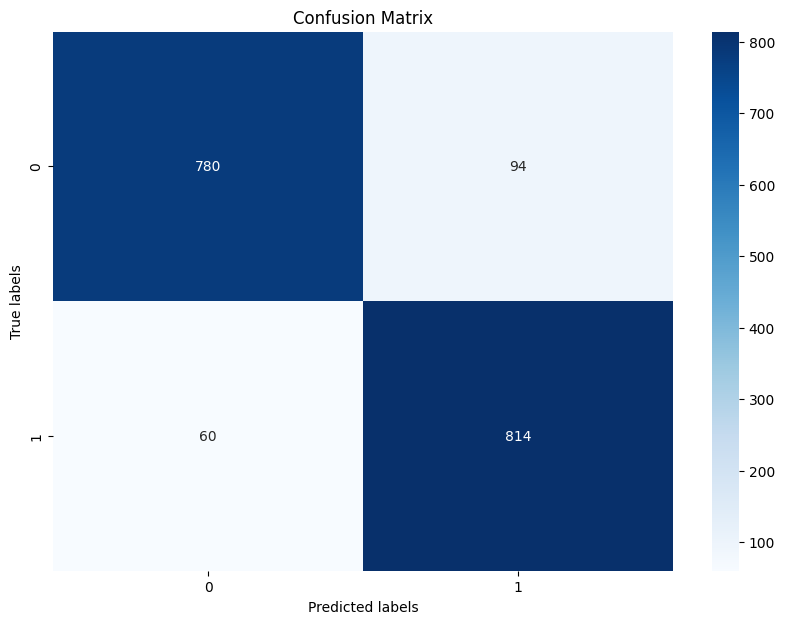

Accuracy training: 0.9118993135011442
[[70 17]
 [12 75]]


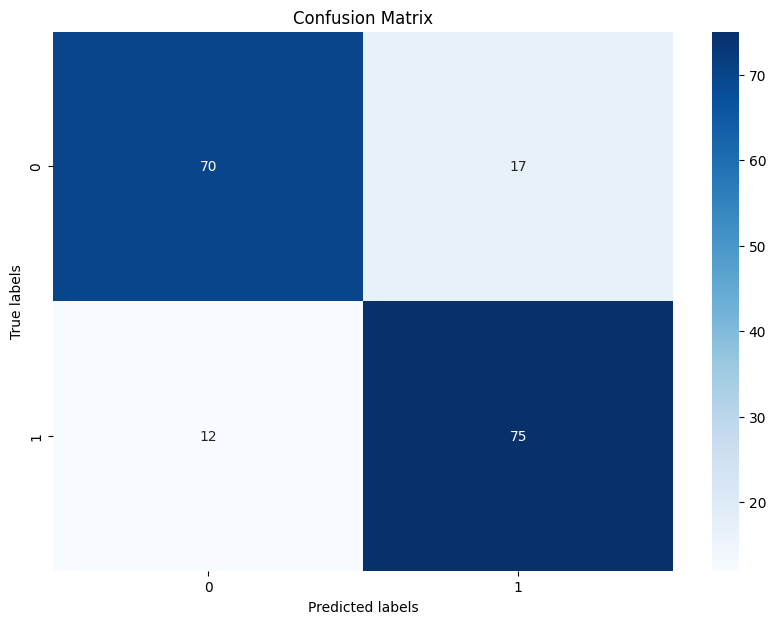

Accuracy validation: 0.8333333333333334


In [100]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

#training
predicted_labels_train = np.rint(predicted_labels_train)
confusion_matrix_train = confusion_matrix(real_labels_train,predicted_labels_train)
print(confusion_matrix_train)

# Plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix_train, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()


accuracy_training = np.sum(np.diag(confusion_matrix_train)) / np.sum(confusion_matrix_train)
print("Accuracy training:", accuracy_training)

#validation
predicted_labels_val = np.rint(predicted_labels_val)
confusion_matrix_val = confusion_matrix(real_labels_val,predicted_labels_val)
print(confusion_matrix_val)

# Plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix_val, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()


accuracy_validation = np.sum(np.diag(confusion_matrix_val)) / np.sum(confusion_matrix_val)
print("Accuracy validation:", accuracy_validation)

#[[TN, FP],
# [FN, TP]]

#TN (True Negative): Actual class is negative (0), and the model predicted negative (0).
#FP (False Positive): Actual class is negative (0), but the model predicted positive (1).
#FN (False Negative): Actual class is positive (1), but the model predicted negative (0).
#TP (True Positive): Actual class is positive (1), and the model predicted positive (1).


---
# Testing

In [101]:
def test(model, test_loader):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)  # Move the model to the sapme device as the input tensor

    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    test_losses=[]

    model.eval()
    test_loss = 0.0
    real_labels = np.array(())
    predicted_labels = np.array(())
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)  # Move input data to the same device as the model

            outputs = model(inputs)
            cpu_outputs= outputs.detach().cpu().numpy()
            predicted_labels = np.append(predicted_labels,cpu_outputs)

            cpu_real_labels = labels.detach().cpu().numpy()
            real_labels = np.append(real_labels,cpu_real_labels)

            loss = criterion(outputs, labels)
            test_loss += loss.item() * inputs.size(0)

    test_loss /= len(test_loader.dataset)
    test_losses.append(test_loss)
    print(test_losses)
    return real_labels,predicted_labels

import seaborn as sns
from sklearn.metrics import confusion_matrix

real_labels,predicted_labels=test(model, test_loader)

# Round the predicted labels to obtain binary predictions
predicted_labels_n = np.rint(predicted_labels)

confusion_matrix = confusion_matrix(real_labels,predicted_labels_n)
print(confusion_matrix)

# Plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

# Calculate accuracy
accuracy = np.sum(np.diag(confusion_matrix)) / np.sum(confusion_matrix)
print("Accuracy testing:", accuracy)

#[[TN, FP],
# [FN, TP]]

#TN (True Negative): Actual class is negative (0), and the model predicted negative (0).
#FP (False Positive): Actual class is negative (0), but the model predicted positive (1).
#FN (False Negative): Actual class is positive (1), but the model predicted negative (0).
#TP (True Positive): Actual class is positive (1), and the model predicted positive (1).


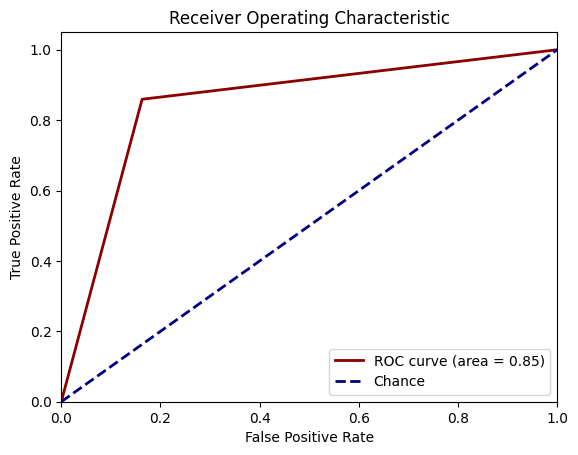

AUC Score: 0.8481481481481481


In [68]:
from sklearn.metrics import roc_curve, roc_auc_score
# Calculate ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(real_labels, predicted_labels)
roc_auc = roc_auc_score(real_labels, predicted_labels)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkred', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label ='Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
# Set font size for x-axis tick labels
plt.xticks(fontsize=10)
# Set font size for y-axis tick labels
plt.yticks(fontsize=10)
plt.xlabel('False Positive Rate', fontsize=10)
plt.ylabel('True Positive Rate', fontsize=10)
plt.title('Receiver Operating Characteristic', fontsize=12)
plt.legend(loc="lower right", fontsize=10)
plt.show()

print("AUC Score:", roc_auc)

In [140]:
# Print model's state_dict
print("Model's state_dict:")
for param_tensor in model.state_dict():
    print(param_tensor, "\t", model.state_dict()[param_tensor].size())

Model's state_dict:
lstm1.weight_ih_l0 	 torch.Size([256, 1280])
lstm1.weight_hh_l0 	 torch.Size([256, 64])
lstm1.bias_ih_l0 	 torch.Size([256])
lstm1.bias_hh_l0 	 torch.Size([256])
lstm1.weight_ih_l1 	 torch.Size([256, 64])
lstm1.weight_hh_l1 	 torch.Size([256, 64])
lstm1.bias_ih_l1 	 torch.Size([256])
lstm1.bias_hh_l1 	 torch.Size([256])
lstm2.weight_ih_l0 	 torch.Size([512, 64])
lstm2.weight_hh_l0 	 torch.Size([512, 128])
lstm2.bias_ih_l0 	 torch.Size([512])
lstm2.bias_hh_l0 	 torch.Size([512])
lstm2.weight_ih_l1 	 torch.Size([512, 128])
lstm2.weight_hh_l1 	 torch.Size([512, 128])
lstm2.bias_ih_l1 	 torch.Size([512])
lstm2.bias_hh_l1 	 torch.Size([512])
fc1.weight 	 torch.Size([64, 128])
fc1.bias 	 torch.Size([64])
fc2.weight 	 torch.Size([1, 64])
fc2.bias 	 torch.Size([1])


In [141]:
torch.save(model.state_dict(), "/home/sergio/Desktop/NEW_ANALYSIS/saved_models_new/saved_models_new/Dataset_6_new/ESM_128_balnew_86") 